

# This notebook runs the **final compound-level GC–MS workflow** :

- **Loads compound identification outputs** (e.g., NIST/CSV exports) for both *samples* and *blanks/QCs*.
- **Cleans and standardizes names/metadata** so compounds are consistent across files (aliases and formatting differences handled).
- **Removes contamination/background signals** by comparing detections in blanks/env/QC versus samples within a retention-time tolerance.
- **Matches identified compounds to the corrected peak tables** (using RT and, where applicable, m/z tolerances) to link IDs to quantitative intensities.
- **Builds compound intensity matrices** (wide + long formats) at the variety/sample level for downstream statistics and modeling.
- **Annotates compounds** with curated potato-aroma information, sensory descriptions, and chemical families.
- **Links compounds to the sensory panel data** by merging on shared sample/variety identifiers, enabling direct comparison between chemical profiles and sensory traits.
- **Generates summaries and plots** (e.g., filtering impact, family distributions, top-compound heatmaps, PCA/clustering/outlier views) for reporting.

Implementation-wise, these steps are executed using the internal module **`compound_analysis.py`** to keep results consistent and reproducible across runs.


In [0]:

import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list
from sklearn.decomposition import PCA
from itertools import combinations
import re
from scipy.stats import spearmanr, pearsonr
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.spatial.distance import pdist, squareform
from pathlib import Path
from sklearn.feature_selection import VarianceThreshold
from scipy.cluster.hierarchy import linkage, fcluster
from matplotlib.patches import Ellipse
from difflib import get_close_matches
from sklearn.impute import KNNImputer
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
import os, importlib.util
!pip install openpyxl
import yaml
import importlib.util
import compound_analysis 
from compound_analysis import (
    assign_aroma_descriptions_and_families,
    plot_aroma_family_distribution
)

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


# Data Aggregation: Combining Sample and Nist library Compound Files

In [0]:


# =====================================================
# 0) LOAD CONFIG
# =====================================================
CONFIG_PATH = "/Volumes/bmqg/default_bronze/fatemeh/config_mixed.yaml"

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

data_paths = config["data_paths"]

base_dir = data_paths["base_compound_dir_new_harvested"]
output_path = data_paths["output_path_newharvested"]

sample_files = data_paths["sample_files_newharvested"]
blank_files = data_paths["blank_files_newharvested"]
env_files = data_paths.get("env_files_newharvested", [])

print(f"Samples: {len(sample_files)} | blanks: {len(blank_files)} | env: {len(env_files)}")

# -----------------------------------------------------
# SAFETY CHECK: no DBFS paths for pandas
# -----------------------------------------------------
assert not output_path.startswith("/dbfs"), f" pandas cannot write to DBFS: {output_path}"

# =====================================================
# 1) LOAD MODULE (UNCHANGED)
# =====================================================
DP_PATH = "/Workspace/Users/fatemeh.monfared@hzpc.com/aroma_flavor_project/final_flavor_project/compound_analysis.py"

spec = importlib.util.spec_from_file_location("compound_analysis", DP_PATH)
cam = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cam)

print("cam loaded from:", DP_PATH)
print("has combine_compound_data:", hasattr(cam, "combine_compound_data"))

# =====================================================
# 2) COMBINE SAMPLE + BLANK (MODULE)
# =====================================================
combined_df = cam.combine_compound_data(
    base_dir=base_dir,
    sample_files=sample_files,
    blank_files=blank_files,
    output_path=output_path
)

# =====================================================
# 3) STANDARDIZE COLUMNS
# =====================================================
rename_map = {
    "Component": "Component RT",
    "Compound": "Compound Name",
    "Name": "Compound Name"
}

combined_df = combined_df.rename(
    columns={k: v for k, v in rename_map.items() if k in combined_df.columns}
)

combined_df["FileType"] = combined_df["FileType"].fillna("sample")

# =====================================================
# 4) ADD ENV FILES (AS-IS)
# =====================================================
env_dfs = []

for env_path in env_files:
    assert os.path.exists(env_path), f" Env file not found: {env_path}"

    env_df = pd.read_csv(env_path)
    env_df = env_df.rename(
        columns={k: v for k, v in rename_map.items() if k in env_df.columns}
    )

    env_df["FileType"] = "env"
    env_df["FileName"] = os.path.basename(env_path)
    env_df["FilePath"] = env_path

    env_dfs.append(env_df)

if env_dfs:
    combined_df = pd.concat([combined_df] + env_dfs, ignore_index=True)

# =====================================================
# 5) SAVE FINAL FILE (SAFE)
# =====================================================
out_dir = os.path.dirname(output_path)
if out_dir:
    os.makedirs(out_dir, exist_ok=True)

combined_df.to_csv(output_path, index=False)

# =====================================================
# 6) FINAL CHECK
# =====================================================
print("\nFinal FileType counts:")
print(combined_df["FileType"].value_counts())

print("\nSaved to:")
print(output_path)


Samples: 94 | blanks: 1 | env: 1
cam loaded from: /Workspace/Users/fatemeh.monfared@hzpc.com/aroma_flavor_project/final_flavor_project/compound_analysis.py
has combine_compound_data: True

Combined file saved to: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/combined.csv
FileType
sample    8054
blank       58
Name: count, dtype: int64
   Component RT  ...                                           FilePath
0     23.426583  ...  /Volumes/bmqg/default_bronze/fatemeh/data/new ...
1     22.876750  ...  /Volumes/bmqg/default_bronze/fatemeh/data/new ...
2     22.722417  ...  /Volumes/bmqg/default_bronze/fatemeh/data/new ...
3     22.683833  ...  /Volumes/bmqg/default_bronze/fatemeh/data/new ...
4     22.243333  ...  /Volumes/bmqg/default_bronze/fatemeh/data/new ...

[5 rows x 9 columns]

Final FileType counts:
FileType
sample    8054
blank       58
env         53
Name: count, dtype: int64

Saved to:
/Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_n

#  Contamination filtering

Sample compounds before filtering: 8054
Sample compounds after filtering: 6083
Removed 1971 sample peaks (ΔRT ≤ 0.4)
      Component RT  ...                                           FilePath
2797      2.025017  ...  /Volumes/bmqg/default_bronze/fatemeh/data/new ...
177       2.025083  ...  /Volumes/bmqg/default_bronze/fatemeh/data/new ...
1878      2.025100  ...  /Volumes/bmqg/default_bronze/fatemeh/data/new ...
1946      2.025250  ...  /Volumes/bmqg/default_bronze/fatemeh/data/new ...
2186      2.028233  ...  /Volumes/bmqg/default_bronze/fatemeh/data/new ...
...            ...  ...                                                ...
271      23.429683  ...  /Volumes/bmqg/default_bronze/fatemeh/data/new ...
3804     23.432850  ...  /Volumes/bmqg/default_bronze/fatemeh/data/new ...
3307     23.436133  ...  /Volumes/bmqg/default_bronze/fatemeh/data/new ...
446      23.445733  ...  /Volumes/bmqg/default_bronze/fatemeh/data/new ...
1493     23.494000  ...  /Volumes/bmqg/default_bronze/fate

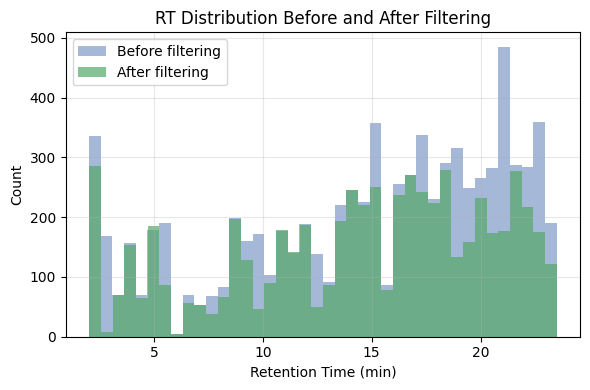

 RT distribution plot generated successfully.


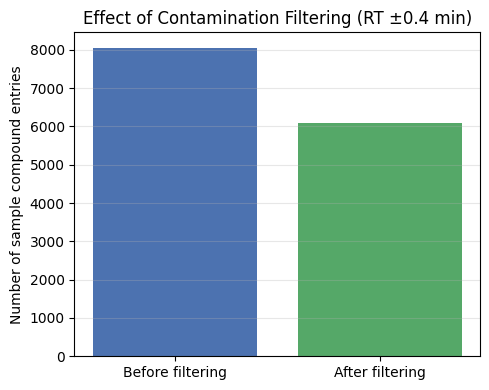

 Filtering effect plot generated successfully. (Before: 8054, After: 6083)


In [0]:

real_compounds = cam.filter_real_compounds(combined_df, rt_tolerance=0.4)
print(real_compounds)
cam.plot_rt_distribution(combined_df, real_compounds)
cam.plot_filtering_effect(combined_df, real_compounds, rt_tolerance=0.4)


#  Matching NIST-Identified Compounds with GC–MS Peak Intensities

# Checking the presence of known potato aroma compounds

In [0]:
import os
import importlib
import pandas as pd
import compound_analysis as cam

importlib.reload(cam)

# ------------------------------------------------------------
# 1) PATHS FROM CONFIG
# ------------------------------------------------------------
sample_cfg = config["sample"]
paths_cfg = config["paths"]

prepared_sample = sample_cfg["output_file_newharvested"]
out_dir = paths_cfg["save_dir"]
master_table_path = paths_cfg["master_table_newharvested"]
aroma_matrix_path = paths_cfg["aroma_matrix_newharvested"]   

assert os.path.exists(prepared_sample), f"prepared sample not found: {prepared_sample}"
assert os.path.exists(master_table_path), f"master table not found: {master_table_path}"

os.makedirs(out_dir, exist_ok=True)
os.makedirs(os.path.dirname(aroma_matrix_path), exist_ok=True) 

# ------------------------------------------------------------
# 2) PREPARED SAMPLE CHECK
# ------------------------------------------------------------
samples_df = pd.read_csv(prepared_sample)
print("prepared_sample:", prepared_sample)
print("samples columns:", list(samples_df.columns)[:10])
display(samples_df.head())

# ------------------------------------------------------------
# 3) LOAD MASTER TABLE + EXTRACT TRUE VARIETY
# ------------------------------------------------------------
master_table = pd.read_excel(master_table_path, engine="openpyxl")
master_table.columns = master_table.columns.astype(str).str.strip()

master_table = master_table.rename(columns={
    "filename": "Filename",
    "sample": "Sample",
})

master_table["Filename"] = master_table["Filename"].astype(str).str.strip()
master_table["Sample"] = master_table["Sample"].astype(str).str.strip()

def extract_variety(sample_value):
    s = str(sample_value).strip()
    if ";" in s:
        return s.split(";")[-1].strip()
    return s

master_table["Variety_clean"] = master_table["Sample"].apply(extract_variety)

print(master_table[["Filename", "Sample", "Variety_clean"]].head(20))

# ------------------------------------------------------------
# 4) INPUT DATAFRAME
# ------------------------------------------------------------
real_compounds = combined_df.copy()

rename_map = {
    "Component": "Component RT",
    "Compound": "Compound Name",
    "Name": "Compound Name",
}

real_compounds = real_compounds.rename(
    columns={k: v for k, v in rename_map.items() if k in real_compounds.columns}
)

if "FileType" not in real_compounds.columns:
    real_compounds["FileType"] = "sample"

print("Combined rows:", len(real_compounds))

# ------------------------------------------------------------
# 5) MATCH POTATO AROMAS
# ------------------------------------------------------------
res = cam.match_potato_aromas_strict_from_notebook(
    combined_df=real_compounds,
    samples_filtered_path=prepared_sample,
    out_dir=out_dir,
    paths=config["paths"],
    rt_tol=0.4,
    mz_tol=0.5
)

print("res keys:", list(res.keys()))

matched = res["matched_per_variety"].copy()

# ------------------------------------------------------------
# 6) REPLACE Variety WITH TRUE VARIETY NAME
# ------------------------------------------------------------
matched["Variety_raw"] = matched["Variety"].astype(str).str.strip()

matched["Filename_key"] = matched["Variety_raw"].str.replace(
    r"^s\d+\s+",
    "",
    regex=True
).str.strip()

filename_to_variety = (
    master_table.dropna(subset=["Filename", "Variety_clean"])
    .drop_duplicates(subset=["Filename"])
    .set_index("Filename")["Variety_clean"]
    .to_dict()
)

matched["Variety_from_master"] = matched["Filename_key"].map(filename_to_variety)
matched["Variety"] = matched["Variety_from_master"].fillna(matched["Variety_raw"])

print("Unmapped rows:", matched["Variety_from_master"].isna().sum())

display(
    matched[
        ["Variety_raw", "Filename_key", "Variety", "Compound Name", "tR_best", "m/z", "peak_Intensity"]
    ].head(20)
)

# ------------------------------------------------------------
# 7) BUILD + CLEAN AROMA MATRIX
# ------------------------------------------------------------
aroma_matrix = res["aroma_matrix"].copy()

aroma_matrix["Variety_raw"] = aroma_matrix["Variety"].astype(str).str.strip()

aroma_matrix["Filename_key"] = aroma_matrix["Variety_raw"].str.replace(
    r"^s\d+\s+",
    "",
    regex=True
).str.strip()

aroma_matrix["Variety_from_master"] = aroma_matrix["Filename_key"].map(filename_to_variety)
aroma_matrix["Variety"] = aroma_matrix["Variety_from_master"].fillna(aroma_matrix["Variety_raw"])

aroma_matrix = aroma_matrix.drop(columns=["Variety_raw", "Filename_key", "Variety_from_master"])

print("Aroma matrix shape:", aroma_matrix.shape)
display(aroma_matrix.head())

# ------------------------------------------------------------
# 8) SAVE AS aroma_matrix_newharvested
# ------------------------------------------------------------
aroma_matrix.to_csv(aroma_matrix_path, index=False)

# optional: keep in result dict too
res["aroma_matrix_newharvested"] = aroma_matrix

print(f"Saved aroma matrix to: {aroma_matrix_path}")

prepared_sample: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/df_corrected.csv
samples columns: ['Peak', 'tR_best', 'm/z', 's199 S962_1_B1_D1_T1', 's221 S962_2_B1_D1_T1', 's243 S962_3_B1_D1_T1', 's265 S962_4_B1_D1_T1', 's287 S962_5_B1_D1_T1', 's309 S962_6_B1_D1_T1', 's331 S962_7_B1_D1_T1']


Peak,tR_best,m/z,s199 S962_1_B1_D1_T1,s221 S962_2_B1_D1_T1,s243 S962_3_B1_D1_T1,s265 S962_4_B1_D1_T1,s287 S962_5_B1_D1_T1,s309 S962_6_B1_D1_T1,s331 S962_7_B1_D1_T1,s353 S962_8_B1_D1_T1,s375 S962_9_B1_D1_T1,s21 S962_10_B1_D1_T1,s39 S962_11_B1_D1_T1,s61 S962_12_B1_D1_T1,s83 S962_13_B1_D2_T1,s105 S962_14_B1_D2_T1,s127 S962_15_B1_D2_T1,s149 S962_16_B1_D2_T1,s171 S962_17_B1_D2_T1,s193 S962_18_B1_D2_T1,s197 S962_19_B1_D2_T1,s201 S962_20_B1_D2_T1,s203 S962_21_B1_D2_T1,s205 S962_22_B1_D2_T1,s207 S962_23_B1_D2_T1,s209 S962_24_B1_D2_T1,s211 S962_25_B1_D3_T1,s213 S962_26_B1_D3_T1,s215 S962_27_B1_D3_T1,s217 S962_28_B1_D3_T1,s219 S962_29_B1_D3_T1,s223 S962_30_B1_D3_T1,s225 S962_31_B1_D3_T1,s227 S962_32_B1_D3_T1,s229 S962_33_B1_D3_T1,s231 S962_34_B1_D3_T1,s233 S962_35_B1_D3_T1,s235 S962_36_B1_D3_T1,s237 S962_37_B1_D4_T1,s239 S962_38_B1_D4_T1,s241 S962_39_B1_D4_T1,s245 S962_40_B1_D4_T1,s247 S962_41_B1_D4_T1,s249 S962_42_B1_D4_T1,s251 S962_43_B1_D4_T1,s253 S962_44_B1_D4_T1,s255 S962_45_B1_D4_T1,s257 S962_46_B1_D4_T1,s259 S962_47_B1_D4_T1,s261 S962_48_B1_D4_T1,s263 S962_49_B1_D5_T1,s267 S962_50_B1_D5_T1,s269 S962_51_B1_D5_T1,s271 S962_52_B1_D5_T1,s273 S962_53_B1_D5_T1,s275 S962_54_B1_D5_T1,s277 S962_55_B1_D5_T1,s279 S962_56_B1_D5_T1,s281 S962_57_B1_D5_T1,s283 S962_58_B1_D5_T1,s285 S962_59_B1_D5_T1,s289 S962_60_B1_D5_T1,s291 S962_61_B1_D6_T1,s293 S962_62_B1_D6_T1,s295 S962_63_B1_D6_T1,s297 S962_64_B1_D6_T1,s299 S962_65_B1_D6_T1,s301 S962_66_B1_D6_T1,s303 S962_67_B1_D6_T1,s305 S962_68_B1_D6_T1,s307 S962_69_B1_D6_T1,s311 S962_70_B1_D6_T1,s313 S962_71_B1_D6_T1,s315 S962_72_B1_D6_T1,s317 S962_73_B1_D7_T1,s319 S962_74_B1_D7_T1,s321 S962_75_B1_D7_T1,s323 S962_76_B1_D7_T1,s325 S962_77_B1_D7_T1,s327 S962_78_B1_D7_T1,s329 S962_79_B1_D7_T1,s333 S962_80_B1_D7_T1,s335 S962_81_B1_D7_T1,s337 S962_82_B1_D7_T1,s339 S962_83_B1_D7_T1,s341 S962_84_B1_D7_T1,s345 S962_86_B1_D8_T1,s347 S962_87_B1_D8_T1,s349 S962_88_B1_D8_T1,s351 S962_89_B1_D8_T1,s355 S962_90_B1_D8_T1,s357 S962_91_B1_D8_T1,s359 S962_92_B1_D8_T1,s361 S962_93_B1_D8_T1,s363 S962_94_B1_D8_T1,s365 S962_95_B1_D8_T1,s367 S962_96_B1_D8_T1,s369 S962_97_B1_D9_T1,s371 S962_98_B1_D9_T1,s373 S962_99_B1_D9_T1,s1 S962_100_B1_D9_T1,s3 S962_101_B1_D9_T1,s5 S962_102_B1_D9_T1,s7 S962_103_B1_D9_T1,s9 S962_104_B1_D9_T1,s11 S962_105_B1_D9_T1,s13 S962_106_B1_D9_T1,s15 S962_107_B1_D9_T1,s17 S962_108_B1_D9_T1,s19 S962_109_B1_D10_T1,s23 S962_110_B1_D10_T1,s25 S962_111_B1_D10_T1,s27 S962_112_B1_D10_T1,s29 S962_113_B1_D10_T1,s30 S962_114_B1_D10_T1,s32 S962_115_B1_D10_T1,s33 S962_116_B1_D10_T1,s34 S962_117_B1_D10_T1,s36 S962_118_B1_D10_T1,s37 S962_119_B1_D10_T1,s41 S962_120_B1_D10_T1,s43 S962_121_B1_D11_T1,s45 S962_122_B1_D11_T1,s47 S962_123_B1_D11_T1,s49 S962_124_B1_D11_T1,s51 S962_125_B1_D11_T1,s53 S962_126_B1_D11_T1,s55 S962_127_B1_D11_T1,s57 S962_128_B1_D11_T1,s59 S962_129_B1_D11_T1,s63 S962_130_B1_D11_T1,s65 S962_131_B1_D11_T1,s67 S962_132_B1_D11_T1,s69 S962_133_B1_D12_T1,s71 S962_134_B1_D12_T1,s73 S962_135_B1_D12_T1,s75 S962_136_B1_D12_T1,s77 S962_137_B1_D12_T1,s79 S962_138_B1_D12_T1,s81 S962_139_B1_D12_T1,s85 S962_140_B1_D12_T1,s87 S962_141_B1_D12_T1,s89 S962_142_B1_D12_T1,s91 S962_143_B1_D12_T1,s93 S962_144_B1_D12_T1,s95 S962_145_B1_D13_T1,s97 S962_146_B1_D13_T1,s99 S962_147_B1_D13_T1,s101 S962_148_B1_D13_T1,s103 S962_149_B1_D13_T1,s107 S962_150_B1_D13_T1,s109 S962_151_B1_D13_T1,s111 S962_152_B1_D13_T1,s113 S962_153_B1_D13_T1,s115 S962_154_B1_D13_T1,s117 S962_155_B1_D13_T1,s119 S962_156_B1_D13_T1,s121 S962_157_B1_D14_T1,s123 S962_158_B1_D14_T1,s125 S962_159_B1_D14_T1,s129 S962_160_B1_D14_T1,s131 S962_161_B1_D14_T1,s133 S962_162_B1_D14_T1,s135 S962_163_B1_D14_T1,s137 S962_164_B1_D14_T1,s139 S962_165_B1_D14_T1,s141 S962_166_B1_D14_T1,s143 S962_167_B1_D14_T1,s145 S962_168_B1_D14_T1,s147 S962_169_B1_D15_T1,s151 S962_170_B1_D15_T1,s153 S962_171_B1_D15_T1,s155 S962_172_B1_D15_T1,s157 S962_173_B1_D15_T1,s159 S962_174_B1_D15_T1,s161 S962_175_B1_D15_T1,s165 S962_177_B1_D15_T1,s167 S962_178_B1_D15_T1,s169 S962_179_B1_D15_T1,s173 S

                  Filename                              Sample  Variety_clean
0      S962_Blank_B1_D1_T1                               Blank          Blank
1      S962_Blank_B1_D1_T2                               Blank          Blank
2        S962_QCB_B1_D1_T1                                 QCB            QCB
3        S962_QC1_B1_D1_T1                                 QC1            QC1
4        S962_QC2_B1_D1_T1                                 QC2            QC2
5        S962_QC3_B1_D1_T1                                 QC3            QC3
6        S962_QC4_B1_D1_T1                                 QC4            QC4
7      S962_Blank_B1_D1_T3                               Blank          Blank
8   S962_EnvBlank_B1_D1_T1                            EnvBlank       EnvBlank
9          S962_1_B1_D1_T1  NLD;SWI;96;28;2025;1;RANGER RUSSET  RANGER RUSSET
10         S962_2_B1_D1_T1   NLD;SWI;96;28;2025;2;RED SCARLETT   RED SCARLETT
11         S962_3_B1_D1_T1      NLD;SWI;96;28;2025;3;DELIA RED  

Variety_raw,Filename_key,Variety,Compound Name,tR_best,m/z,peak_Intensity
s199 S962_1_B1_D1_T1,S962_1_B1_D1_T1,RANGER RUSSET,(E)-2-Decenal,10.745,57.0,728986.0
s199 S962_1_B1_D1_T1,S962_1_B1_D1_T1,RANGER RUSSET,"1-Hexanol, 2-ethyl-",10.745,57.0,728986.0
s199 S962_1_B1_D1_T1,S962_1_B1_D1_T1,RANGER RUSSET,1-Octen-3-ol,9.977,57.0,40525.0
s199 S962_1_B1_D1_T1,S962_1_B1_D1_T1,RANGER RUSSET,1-Octyn-3-ol,10.745,57.0,728986.0
s199 S962_1_B1_D1_T1,S962_1_B1_D1_T1,RANGER RUSSET,1-Pentanol,4.893,55.0,30252.0
s199 S962_1_B1_D1_T1,S962_1_B1_D1_T1,RANGER RUSSET,1-Penten-3-one,15.501,121.0,7300.0
s199 S962_1_B1_D1_T1,S962_1_B1_D1_T1,RANGER RUSSET,"2,3-Butanedione",2.556,43.0,853347.0
s199 S962_1_B1_D1_T1,S962_1_B1_D1_T1,RANGER RUSSET,"2,3-Pentanedione",3.561,44.0,38368.0
s199 S962_1_B1_D1_T1,S962_1_B1_D1_T1,RANGER RUSSET,2-Ethylfuran,3.416,81.0,163421.0
s199 S962_1_B1_D1_T1,S962_1_B1_D1_T1,RANGER RUSSET,2-Methylpropanal,2.38,72.0,241220.0


Aroma matrix shape: (188, 39)


Variety,(E)-2-Decenal,"1-Hexanol, 2-ethyl-",1-Octen-3-ol,1-Octyn-3-ol,1-Pentanol,1-Penten-3-one,"2,3-Butanedione","2,3-Pentanedione",2-Ethylfuran,2-Methylpropanal,"2-Propanone, 1-methoxy-",3-Carene,3-Methylbutanal,6-Methyl-5-hepten-2-one,"Acetic acid, ethenyl ester","Acetic acid, methyl ester",Benzaldehyde,Benzoic acid,Benzyl alcohol,"Butanal, 3-methyl-",Butanoic acid,Decanal,Dimethyl disulfide,Dimethyl phthalate,Dimethyl trisulfide,Ethyl hexanoate,Eucalyptol,"Furan, 2-pentyl-",Hexanal,Hexanoic acid,Hexanol,Linalool,Nonanal,Pentanal,Phenol,Tetradecane,Tridecane,nonanoic acid
BLUE STAR,2312749.0,2312749.0,39357.0,2312749.0,316236.0,4027.0,1064411.0,45168.0,65130.0,59866.0,307660.0,30310.0,1740193.0,44539.0,1064411.0,414317.0,644927.0,21551.0,64463.0,56768.0,120362.0,150191.0,529520.0,309353.0,56474.0,68909.0,2312749.0,32888.0,56256.0,120362.0,45168.0,15253.0,139752.0,45168.0,131697.0,311784.0,138261.0,92633.0
EL MUNDO,1276112.0,1276112.0,65636.0,1276112.0,448424.0,8600.0,1434245.0,88056.0,195348.0,110847.0,353284.0,21457.0,773541.0,31465.0,1434245.0,413989.0,526239.0,18925.0,60027.0,202600.0,80557.0,159078.0,329539.0,202522.0,66913.0,96961.0,1276112.0,30416.0,175032.0,80557.0,88056.0,78497.0,132296.0,88056.0,151516.0,311819.0,126033.0,97843.0
INNOVATOR,504399.0,504399.0,33094.0,504399.0,174987.0,7681.0,585745.0,30272.0,40588.0,47704.0,260467.0,19350.0,1099442.0,7572.0,585745.0,268985.0,239005.0,13962.0,117705.0,48044.0,68173.0,126247.0,319895.0,130904.0,37607.0,86897.0,504399.0,12008.0,29168.0,68173.0,30272.0,46229.0,57168.0,30272.0,64700.0,339253.0,64602.0,48344.0
CARLITA,1505257.0,1505257.0,32515.0,1505257.0,94728.0,23109.0,2011418.0,585680.0,736198.0,470354.0,1289128.0,38371.0,846315.0,164013.0,2011418.0,1461553.0,1023388.0,89984.0,47797.0,55592.0,212838.0,271188.0,647608.0,104440.0,157684.0,69588.0,1505257.0,79480.0,2122032.0,212838.0,585680.0,15660.0,205904.0,585680.0,102968.0,476040.0,62300.0,116314.0
FARIDA,550658.0,550658.0,25686.0,550658.0,181402.0,6128.0,307262.0,29744.0,41314.0,33095.0,829431.0,17560.0,774823.0,7081.0,307262.0,360074.0,275827.0,12319.0,353356.0,31833.0,75876.0,151095.0,230737.0,107177.0,26314.0,60501.0,550658.0,15392.0,24701.0,75876.0,29744.0,40389.0,72088.0,29744.0,68531.0,320392.0,65030.0,56863.0


Saved aroma matrix to: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/matched_per_variety_STRICT_ONLY.csv


# Classification of Aroma Compounds by Chemical Family

/Workspace/Users/fatemeh.monfared@hzpc.com/aroma_flavor_project/final_flavor_project/compound_analysis.py:1405: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


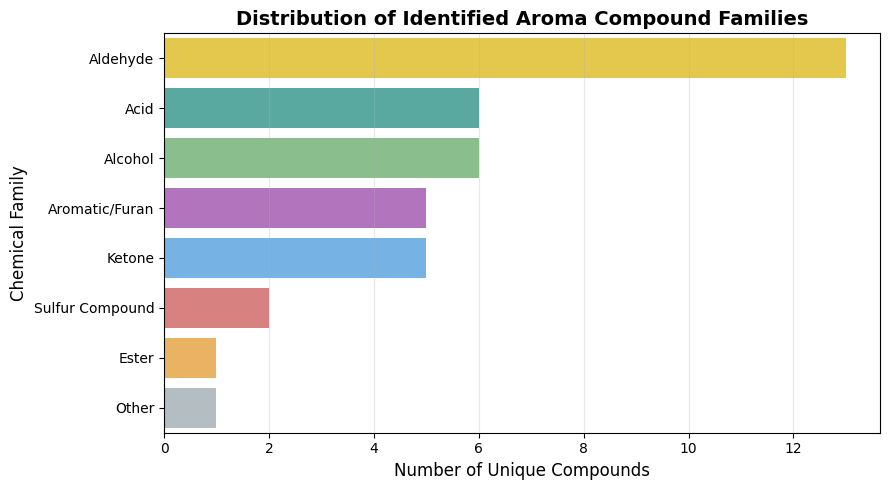

Chemical_Family
Aldehyde           13
Acid                6
Alcohol             6
Aromatic/Furan      5
Ketone              5
Sulfur Compound     2
Ester               1
Other               1
dtype: int64

In [0]:


# 1) wide -> long
id_col = aroma_matrix.index.name or "Variety"

aroma_long = (
    aroma_matrix
    .reset_index()
    .melt(
        id_vars=[id_col],
        var_name="Compound Name",
        value_name="Intensity"
    )
    .rename(columns={id_col: "Variety"})
)

# 2) numeric cleanup
aroma_long["Intensity"] = (
    aroma_long["Intensity"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

aroma_long["Intensity"] = pd.to_numeric(aroma_long["Intensity"], errors="coerce")

# 3) filter
aroma_long = aroma_long.dropna(subset=["Intensity"])
aroma_long = aroma_long.loc[aroma_long["Intensity"] > 0].copy()

# 4) annotate (IMPORTANT: unpack!)
aroma_long, aroma_desc_map, chemical_family_map = (
    assign_aroma_descriptions_and_families(aroma_long)
)

# 5) plot
plot_aroma_family_distribution(aroma_long)


# Run PCA and clustering 

Explained variance (2 PCs): 40.91%
Optimal number of clusters (based on silhouette): 3


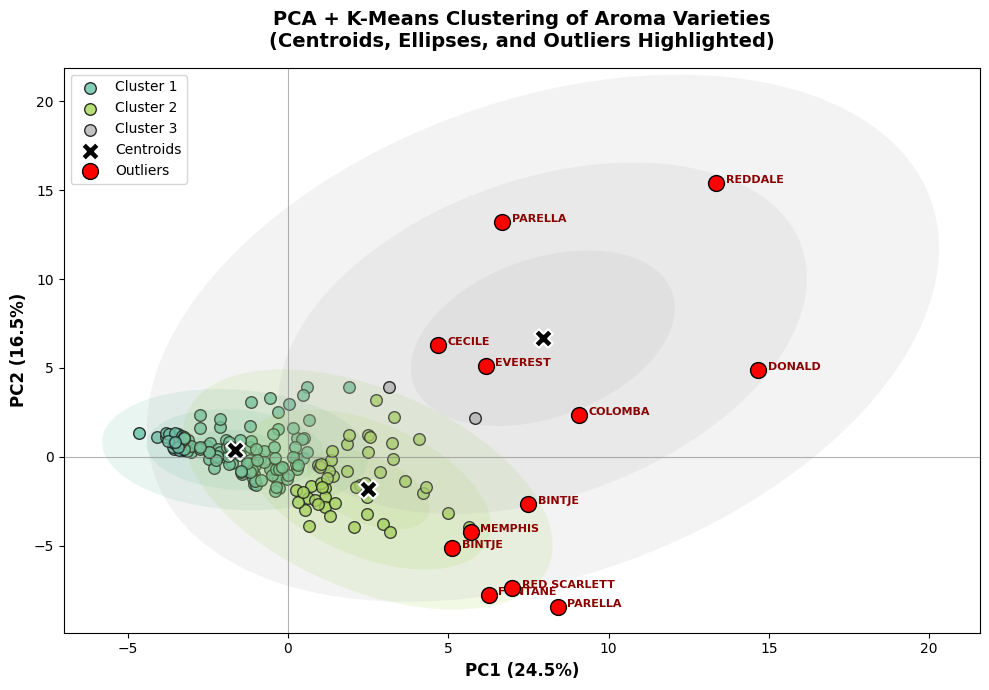


Results saved in: aroma_pca_kmeans


In [0]:

results, X_pca, clusters = cam.pca_kmeans_aroma(aroma_matrix)


Optimal PCA components: 15 (explains 91.0% variance)


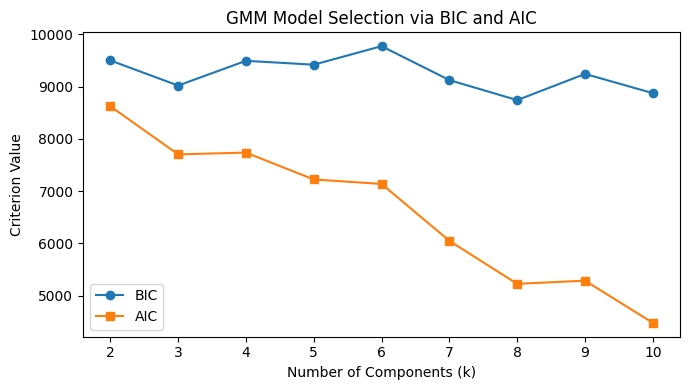

Best number of clusters (based on BIC): 8

Clustering metrics for k=8:
 Silhouette Score:       0.149
 Davies–Bouldin Index:   1.874
 Calinski–Harabasz:      22.6

Outliers detected (6): ['CAROLINA', 'AVARNA', 'ESCORT', 'REDDALE', 'PARELLA', 'DONALD']


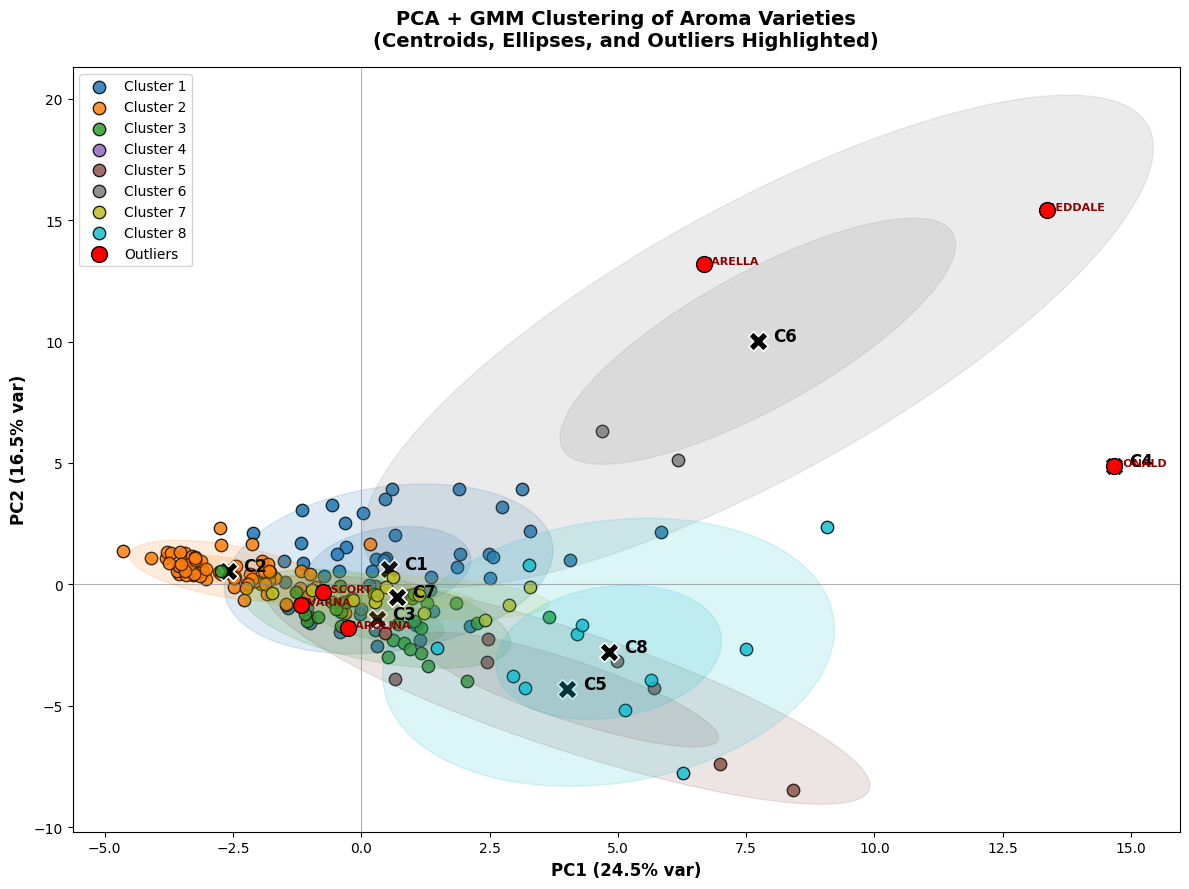

/databricks/python/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


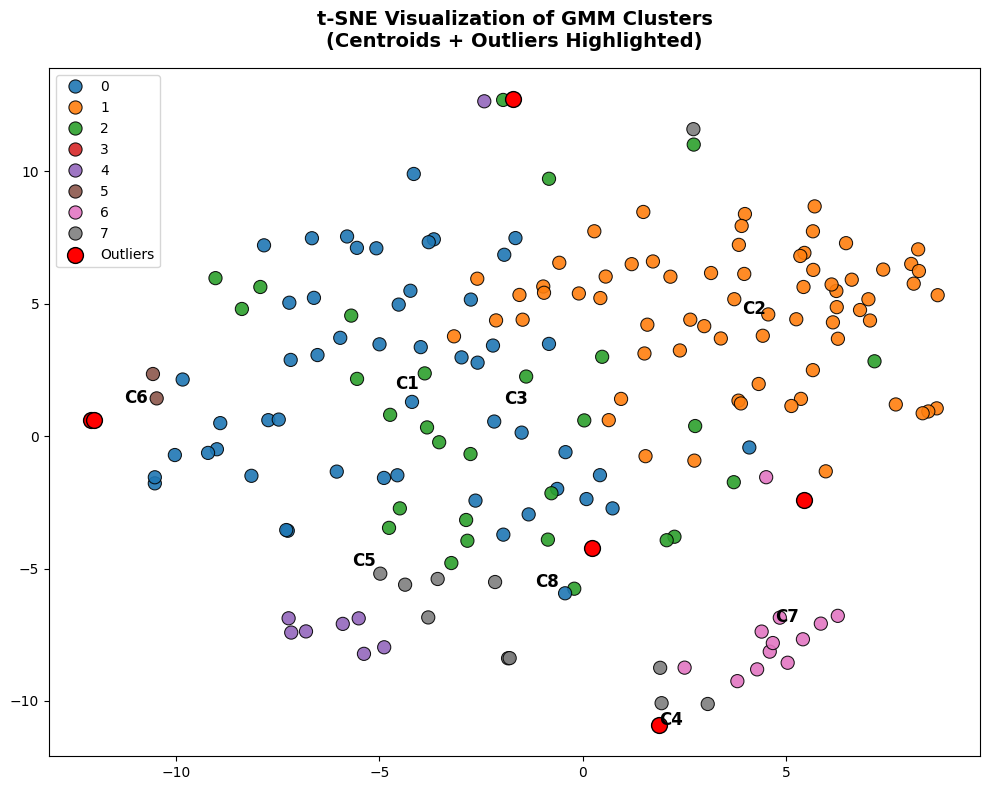


Results saved in: aroma_cluster_results


In [0]:

# --- Run function ---
results, cluster_means = cam.analyze_aroma_clusters_gmm(aroma_matrix)

# Comparative Analysis of Aroma Compound Classes Between Outlier and Inlier Potato Varieties



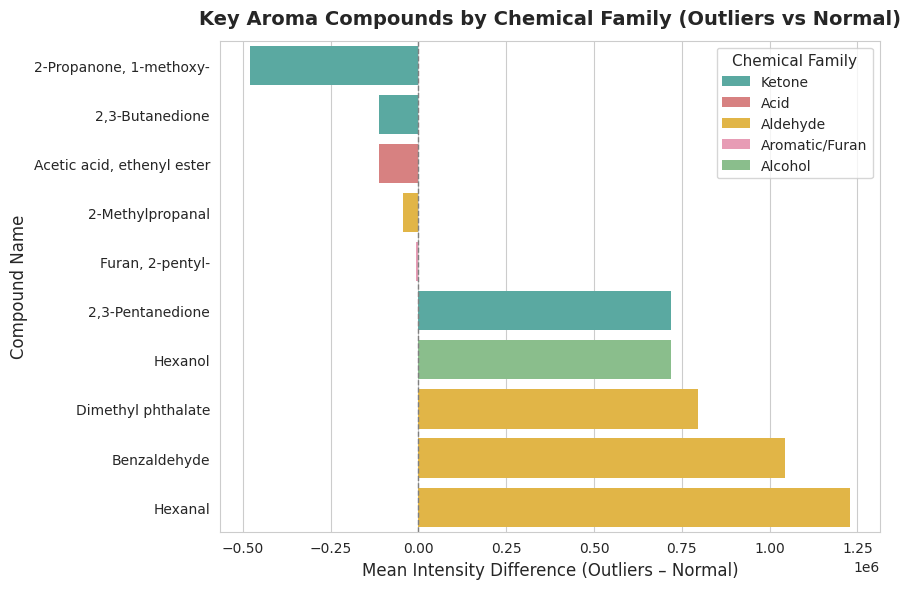

Saved: aroma_cluster_results/outlier_vs_normal_aromas.png


(group               Compound Name  ...  Chemical Family
 10        2-Propanone, 1-methoxy-  ...           Ketone
 6                 2,3-Butanedione  ...           Ketone
 14     Acetic acid, ethenyl ester  ...             Acid
 9                2-Methylpropanal  ...         Aldehyde
 27               Furan, 2-pentyl-  ...   Aromatic/Furan
 7                2,3-Pentanedione  ...           Ketone
 30                        Hexanol  ...          Alcohol
 23             Dimethyl phthalate  ...         Aldehyde
 16                   Benzaldehyde  ...         Aldehyde
 28                        Hexanal  ...         Aldehyde
 
 [10 rows x 6 columns],
 group               Compound Name  ...  Chemical Family
 0                   (E)-2-Decenal  ...         Aldehyde
 1             1-Hexanol, 2-ethyl-  ...          Alcohol
 2                    1-Octen-3-ol  ...          Alcohol
 3                    1-Octyn-3-ol  ...          Alcohol
 4                      1-Pentanol  ...          Alcohol
 5   

In [0]:

outliers = results.loc[results["is_outlier"], "Variety"].tolist()
cam.plot_outlier_vs_normal_aromas(aroma_matrix, outliers, chemical_family_map=chemical_family_map)

In [0]:
# =========================================================
# CONVERT aroma_matrix → aroma_sample_df
# =========================================================
# safety copy
aroma_sample_df = aroma_matrix.copy()

# ensure Variety is a column (not index)
if aroma_sample_df.index.name == "Variety":
    aroma_sample_df = aroma_sample_df.reset_index()

# basic sanity checks
assert "Variety" in aroma_sample_df.columns, "❌ Variety column missing"
assert "ALTURAS" in aroma_sample_df["Variety"].values, "❌ ALTURAS not found"
assert "DONALD" in aroma_sample_df["Variety"].values, "❌ DONALD not found"

print("aroma_sample_df shape:", aroma_sample_df.shape)
display(aroma_sample_df.head())


aroma_sample_df shape: (188, 39)


Variety,(E)-2-Decenal,"1-Hexanol, 2-ethyl-",1-Octen-3-ol,1-Octyn-3-ol,1-Pentanol,1-Penten-3-one,"2,3-Butanedione","2,3-Pentanedione",2-Ethylfuran,2-Methylpropanal,"2-Propanone, 1-methoxy-",3-Carene,3-Methylbutanal,6-Methyl-5-hepten-2-one,"Acetic acid, ethenyl ester","Acetic acid, methyl ester",Benzaldehyde,Benzoic acid,Benzyl alcohol,"Butanal, 3-methyl-",Butanoic acid,Decanal,Dimethyl disulfide,Dimethyl phthalate,Dimethyl trisulfide,Ethyl hexanoate,Eucalyptol,"Furan, 2-pentyl-",Hexanal,Hexanoic acid,Hexanol,Linalool,Nonanal,Pentanal,Phenol,Tetradecane,Tridecane,nonanoic acid
BLUE STAR,2312749.0,2312749.0,39357.0,2312749.0,316236.0,4027.0,1064411.0,45168.0,65130.0,59866.0,307660.0,30310.0,1740193.0,44539.0,1064411.0,414317.0,644927.0,21551.0,64463.0,56768.0,120362.0,150191.0,529520.0,309353.0,56474.0,68909.0,2312749.0,32888.0,56256.0,120362.0,45168.0,15253.0,139752.0,45168.0,131697.0,311784.0,138261.0,92633.0
EL MUNDO,1276112.0,1276112.0,65636.0,1276112.0,448424.0,8600.0,1434245.0,88056.0,195348.0,110847.0,353284.0,21457.0,773541.0,31465.0,1434245.0,413989.0,526239.0,18925.0,60027.0,202600.0,80557.0,159078.0,329539.0,202522.0,66913.0,96961.0,1276112.0,30416.0,175032.0,80557.0,88056.0,78497.0,132296.0,88056.0,151516.0,311819.0,126033.0,97843.0
INNOVATOR,504399.0,504399.0,33094.0,504399.0,174987.0,7681.0,585745.0,30272.0,40588.0,47704.0,260467.0,19350.0,1099442.0,7572.0,585745.0,268985.0,239005.0,13962.0,117705.0,48044.0,68173.0,126247.0,319895.0,130904.0,37607.0,86897.0,504399.0,12008.0,29168.0,68173.0,30272.0,46229.0,57168.0,30272.0,64700.0,339253.0,64602.0,48344.0
CARLITA,1505257.0,1505257.0,32515.0,1505257.0,94728.0,23109.0,2011418.0,585680.0,736198.0,470354.0,1289128.0,38371.0,846315.0,164013.0,2011418.0,1461553.0,1023388.0,89984.0,47797.0,55592.0,212838.0,271188.0,647608.0,104440.0,157684.0,69588.0,1505257.0,79480.0,2122032.0,212838.0,585680.0,15660.0,205904.0,585680.0,102968.0,476040.0,62300.0,116314.0
FARIDA,550658.0,550658.0,25686.0,550658.0,181402.0,6128.0,307262.0,29744.0,41314.0,33095.0,829431.0,17560.0,774823.0,7081.0,307262.0,360074.0,275827.0,12319.0,353356.0,31833.0,75876.0,151095.0,230737.0,107177.0,26314.0,60501.0,550658.0,15392.0,24701.0,75876.0,29744.0,40389.0,72088.0,29744.0,68531.0,320392.0,65030.0,56863.0


#  Major Contributing Aroma Compounds (Mean Intensity-Based Ranking)


 Total compounds analyzed: 38
 Top 10 aroma compounds by average intensity:

                                  mean         std
Compound Name                                     
(E)-2-Decenal               1751207.69  1636845.95
1-Hexanol, 2-ethyl-         1751207.69  1636845.95
1-Octyn-3-ol                1751207.69  1636845.95
Eucalyptol                  1751207.69  1636845.95
2-Propanone, 1-methoxy-     1450632.30  1933501.10
Acetic acid, ethenyl ester  1294959.00   752266.08
2,3-Butanedione             1294959.00   752266.08
3-Methylbutanal             1117446.22   931484.73
Benzaldehyde                 730761.06   868143.90
Acetic acid, methyl ester    725514.51   493247.86


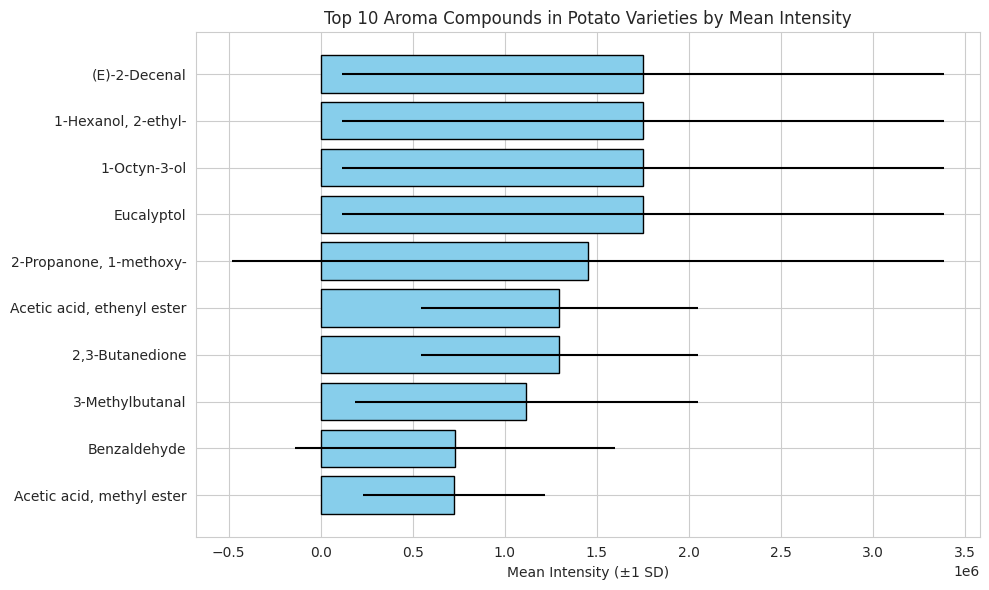

In [0]:
desc_stats, top_compounds = cam.summarize_aroma_intensities(aroma_sample_df, top_n=10)

# Heatmap of Top Aroma Compounds in Potato Varieties


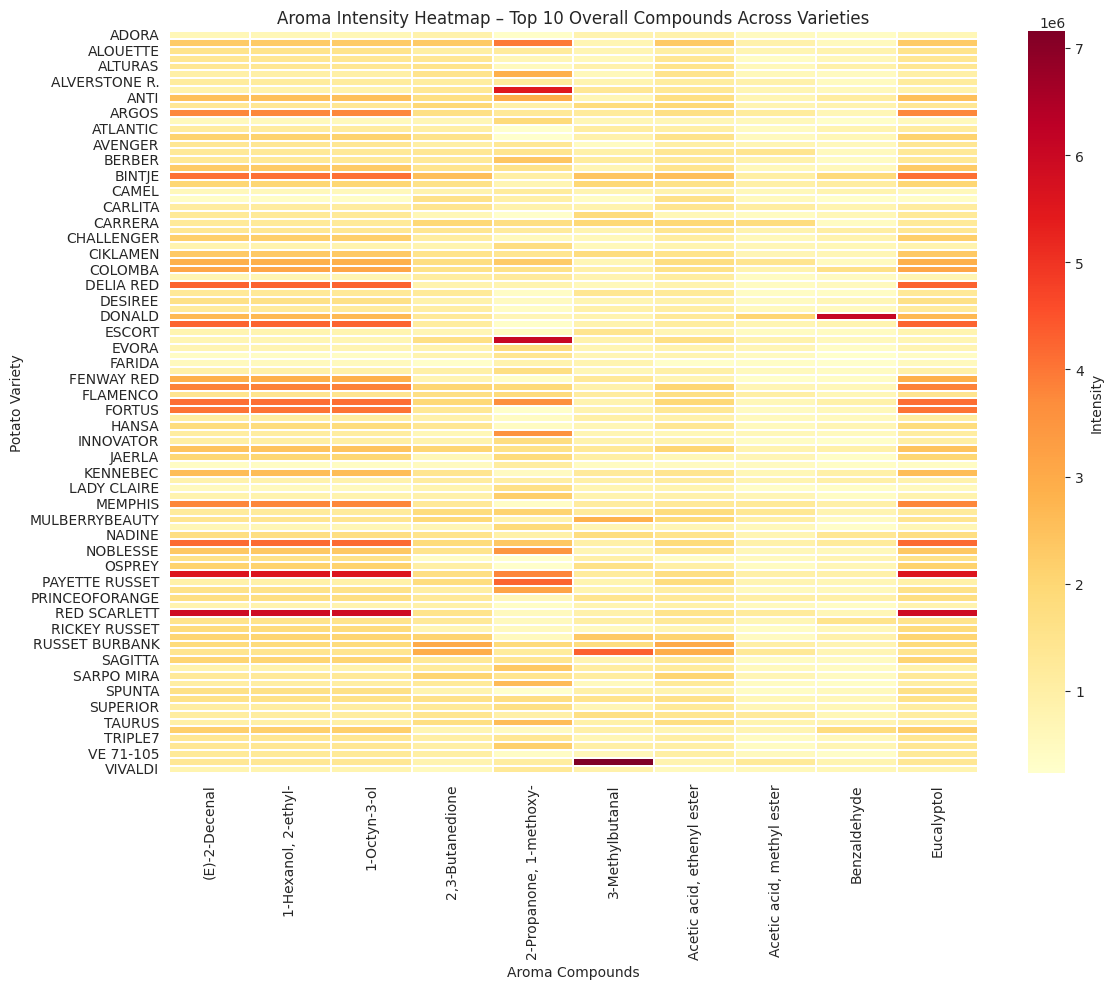

Compound,(E)-2-Decenal,"1-Hexanol, 2-ethyl-",1-Octyn-3-ol,"2,3-Butanedione","2-Propanone, 1-methoxy-",3-Methylbutanal,"Acetic acid, ethenyl ester","Acetic acid, methyl ester",Benzaldehyde,Eucalyptol
Variety,,,,,,,,,,
ADORA,647200.0,647200.0,647200.0,856518.5,294850.0,817597.5,856518.5,500140.0,407940.0,647200.0
AGRIA,2270328.0,2270328.0,2270328.0,2291736.5,3955771.5,735056.5,2291736.5,902290.5,545440.0,2270328.0
ALOUETTE,1525085.5,1525085.5,1525085.5,1034144.0,1199013.0,722551.0,1034144.0,738125.5,839561.0,1525085.5
ALTHEA,1369883.5,1369883.5,1369883.5,1349653.0,680549.5,599122.0,1349653.0,406268.0,629721.0,1369883.5
ALTURAS,1377757.0,1377757.0,1377757.0,1517409.0,530173.5,899734.5,1517409.0,606895.5,928009.5,1377757.0
...,...,...,...,...,...,...,...,...,...,...
TRIPLE7,1355970.0,1355970.0,1355970.0,1025022.5,1341490.5,683627.0,1025022.5,443346.0,560924.0,1355970.0
VAN GOGH,1361520.0,1361520.0,1361520.0,1001917.0,2158045.5,994311.0,1001917.0,425479.0,733585.0,1361520.0
VE 71-105,1251978.0,1251978.0,1251978.0,1021812.0,371406.0,634092.0,1021812.0,524881.5,320296.0,1251978.0


In [0]:
# Show top 10 compounds overall across varieties
cam.plot_top_aroma_heatmap(aroma_sample_df, top_n=10, mode="overall")

# Feature Importance Analysis of Aroma Compounds Using PCA Loadings 

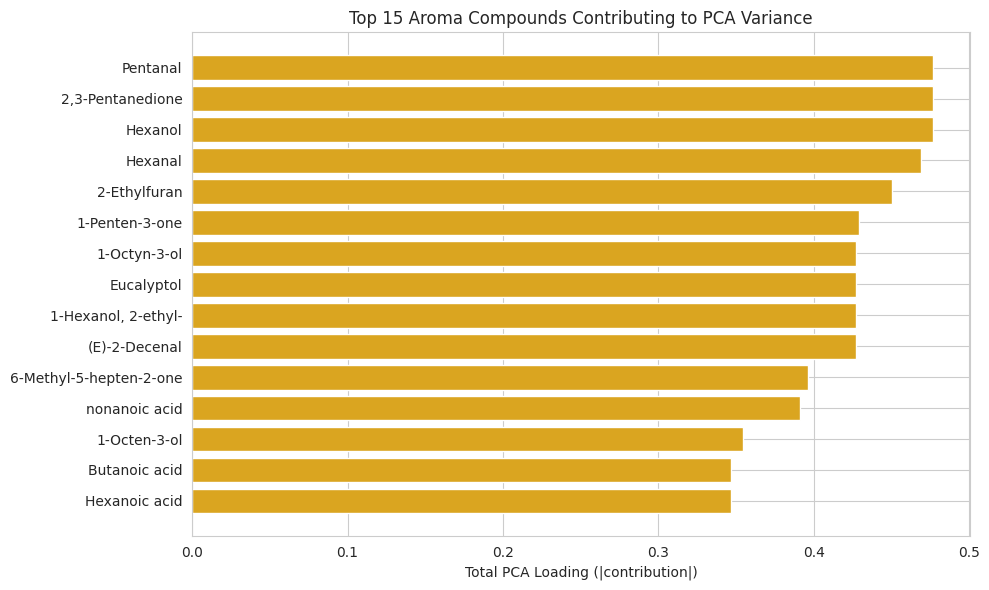

 Top 15 most contributing compounds:
                              PC1       PC2  Total_Importance
Compound Name                                                
Pentanal                 0.185443  0.291168          0.476611
2,3-Pentanedione         0.185443  0.291168          0.476611
Hexanol                  0.185443  0.291168          0.476611
Hexanal                  0.195316  0.273459          0.468775
2-Ethylfuran             0.194489  0.255668          0.450157
1-Penten-3-one           0.190150  0.239268          0.429418
1-Octyn-3-ol             0.203008  0.224148          0.427157
Eucalyptol               0.203008  0.224148          0.427157
1-Hexanol, 2-ethyl-      0.203008  0.224148          0.427157
(E)-2-Decenal            0.203008  0.224148          0.427157
6-Methyl-5-hepten-2-one  0.165167  0.231101          0.396268
nonanoic acid            0.166192  0.225035          0.391227
1-Octen-3-ol             0.191046  0.163588          0.354634
Butanoic acid            0.154842

In [0]:
importance_df = cam.compute_feature_importance_from_pca(aroma_sample_df)


# Joining the sensory panel data 


In [0]:
!pip install openpyxl

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:

# --- Read the sensory Excel file using config path ---
sensory_path = config["paths"]["sensory_data"]
sensory = pd.read_excel(sensory_path)

# --- Print column names and preview the first few rows ---
print("Columns:", list(sensory.columns))
display(sensory.head(config["settings"]["display_rows"]))


Columns: ['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour', 'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness', 'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes', 'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma', 'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel', 'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh', 'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin', 'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47', 'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK', 'cluster 3 Sp, cluster 2 UK', 'cluster 1 Sp, cluster 3 UK.1', 'cluster 2 Sp, cluster 1 UK.1', 'cluster 3 Sp, clus

VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,Visible Ring,Patches/ Blemishes,Waxy/ Shine,Floury/Flaky,Intensity of Aroma,Earthy Aroma,Farmyard,Sweet,Starchy,Damp,Buttery,Fresh,Intensity of Flavour,Potato Starch,Metallic Flavour,Bitter Flavour,Earthy Flavour,Sour Flavour,Fresh Flavour,Sweet Flavour,Root/ Vegetable Flavour,Farmyard (grass/hay) flavour,Acidic,Dry Mouthfeel,Waxy -Flesh,Mushy -Flesh,Crumbly - Flesh,Sticky - Flesh,Soft - Flesh,Chewy - Skin,Thickness - Skin,Starchy Aftertaste,Bitter Aftertaste,Drying Aftertaste,Sour Aftertaste,Sweet Aftertaste,Metalic,Unnamed: 47,"cluster 1 Sp, cluster 3 UK","cluster 2 Sp, cluster 1 UK","cluster 3 Sp, cluster 2 UK","cluster 1 Sp, cluster 3 UK.1","cluster 2 Sp, cluster 1 UK.1","cluster 3 Sp, cluster 2 UK.1",Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,13.333,5.521,24.146,10.583,40.843,18.537,15.953,4.385,21.588,19.845,3.491,29.071,40.979,28.018,17.627,15.329,26.573,10.678,24.014,3.098,17.36,12.52,11.959,36.073,21.58,19.601,15.917,28.364,40.155,30.056,24.854,24.316,15.647,34.603,14.179,1.79,16.498,null,5.1663698,5.689059207999998,5.003401500000001,49.92147255445099,80.60709936506272,88.84804953072177,null,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.13367281985997,471.3
AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,15.167,3.708,28.771,11.667,41.191,16.906,13.953,5.537,21.11,18.888,3.578,31.049,42.109,30.952,10.171,11.633,18.378,7.548,30.34,3.25,10.6,10.672,10.372,35.899,8.733,29.514,15.178,24.712,56.329,23.664,21.441,27.272,10.255,29.06,8.114,2.377,6.802,null,7.062588400000001,6.000016903999999,5.631414000000001,68.24420756214238,85.01299443195812,100.0,null,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.22770058269833,892.4
AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,25.792,10.917,16.937,28.667,38.691,23.58,12.801,3.298,23.219,15.823,1.752,26.592,35.348,35.3,8.018,5.872,20.421,3.787,29.188,1.859,13.447,8.803,4.959,52.508,5.211,15.057,30.069,24.342,47.22,24.012,19.158,31.163,8.777,43.712,4.071,1.203,9.28,null,3.1528587999999997,6.087160967999999,4.4545785,30.465367394385762,86.24772059125799,79.1023089405254,null,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891752577319586,77.6
AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,23.542,6.104,20.333,23.313,40.234,18.276,16.649,4.755,18.567,15.214,3.426,30.462,41.457,28.778,11.192,12.155,20.334,7.135,33.122,2.729,17.447,10.085,6.894,31.138,9.559,27.122,7.7,27.451,56.612,20.903,18.158,25.816,9.038,25.712,8.071,1.681,8.78,null,8.455572800000002,5.608341447999998,5.251437000000001,81.70430337126902,79.46342617359797,93.25254722881323,null,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.93868122637548,238.1
AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,8.5,2.417,29.354,9.375,38.017,19.319,11.605,4.407,18.132,18.584,3.209,30.94,39.022,27.518,13.018,11.176,20.486,11.591,24.644,3.511,15.991,9.846,8.959,33.551,20.167,18.101,13.265,25.842,41.133,20.882,18.245,23.055,11.016,26.625,9.331,3.007,8.107,null,7.631835600000002,6.376880296,4.8261330000000005,73.74471557291199,90.35269362919641,85.70019891984498,null,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.51122375090515,414.3


# Sensory Panel Data Processing

In [0]:

sensory_path = config["paths"]["sensory_data"]

sensory = pd.read_excel(sensory_path, sheet_name=0, engine="openpyxl")  # sheet_name can be name too
print("Shape:", sensory.shape)
print("Columns:", list(sensory.columns))
display(sensory.head(config["settings"]["display_rows"]))


Shape: (63, 64)
Columns: ['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour', 'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness', 'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes', 'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma', 'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel', 'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh', 'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin', 'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47', 'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK', 'cluster 3 Sp, cluster 2 UK', 'cluster 1 Sp, cluster 3 UK.1', 'cluster 2 Sp, cluster 1 UK.1', 'cl

VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,Visible Ring,Patches/ Blemishes,Waxy/ Shine,Floury/Flaky,Intensity of Aroma,Earthy Aroma,Farmyard,Sweet,Starchy,Damp,Buttery,Fresh,Intensity of Flavour,Potato Starch,Metallic Flavour,Bitter Flavour,Earthy Flavour,Sour Flavour,Fresh Flavour,Sweet Flavour,Root/ Vegetable Flavour,Farmyard (grass/hay) flavour,Acidic,Dry Mouthfeel,Waxy -Flesh,Mushy -Flesh,Crumbly - Flesh,Sticky - Flesh,Soft - Flesh,Chewy - Skin,Thickness - Skin,Starchy Aftertaste,Bitter Aftertaste,Drying Aftertaste,Sour Aftertaste,Sweet Aftertaste,Metalic,Unnamed: 47,"cluster 1 Sp, cluster 3 UK","cluster 2 Sp, cluster 1 UK","cluster 3 Sp, cluster 2 UK","cluster 1 Sp, cluster 3 UK.1","cluster 2 Sp, cluster 1 UK.1","cluster 3 Sp, cluster 2 UK.1",Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,13.333,5.521,24.146,10.583,40.843,18.537,15.953,4.385,21.588,19.845,3.491,29.071,40.979,28.018,17.627,15.329,26.573,10.678,24.014,3.098,17.36,12.52,11.959,36.073,21.58,19.601,15.917,28.364,40.155,30.056,24.854,24.316,15.647,34.603,14.179,1.79,16.498,null,5.1663698,5.689059207999998,5.003401500000001,49.92147255445099,80.60709936506272,88.84804953072177,null,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.13367281985997,471.3
AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,15.167,3.708,28.771,11.667,41.191,16.906,13.953,5.537,21.11,18.888,3.578,31.049,42.109,30.952,10.171,11.633,18.378,7.548,30.34,3.25,10.6,10.672,10.372,35.899,8.733,29.514,15.178,24.712,56.329,23.664,21.441,27.272,10.255,29.06,8.114,2.377,6.802,null,7.062588400000001,6.000016903999999,5.631414000000001,68.24420756214238,85.01299443195812,100.0,null,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.22770058269833,892.4
AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,25.792,10.917,16.937,28.667,38.691,23.58,12.801,3.298,23.219,15.823,1.752,26.592,35.348,35.3,8.018,5.872,20.421,3.787,29.188,1.859,13.447,8.803,4.959,52.508,5.211,15.057,30.069,24.342,47.22,24.012,19.158,31.163,8.777,43.712,4.071,1.203,9.28,null,3.1528587999999997,6.087160967999999,4.4545785,30.465367394385762,86.24772059125799,79.1023089405254,null,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891752577319586,77.6
AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,23.542,6.104,20.333,23.313,40.234,18.276,16.649,4.755,18.567,15.214,3.426,30.462,41.457,28.778,11.192,12.155,20.334,7.135,33.122,2.729,17.447,10.085,6.894,31.138,9.559,27.122,7.7,27.451,56.612,20.903,18.158,25.816,9.038,25.712,8.071,1.681,8.78,null,8.455572800000002,5.608341447999998,5.251437000000001,81.70430337126902,79.46342617359797,93.25254722881323,null,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.93868122637548,238.1
AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,8.5,2.417,29.354,9.375,38.017,19.319,11.605,4.407,18.132,18.584,3.209,30.94,39.022,27.518,13.018,11.176,20.486,11.591,24.644,3.511,15.991,9.846,8.959,33.551,20.167,18.101,13.265,25.842,41.133,20.882,18.245,23.055,11.016,26.625,9.331,3.007,8.107,null,7.631835600000002,6.376880296,4.8261330000000005,73.74471557291199,90.35269362919641,85.70019891984498,null,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.51122375090515,414.3


In [0]:

# flavor-related columns
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste", 'Earthy Aroma',
    'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Potato Starch','Metalic'
]

sensory_summary = cam.summarize_sensory_traits(sensory, sensory_cols)

 Rows (unique varieties): 59
 Traits averaged: 20

 Example of summarized sensory data:
  VARIETY  Metallic Flavour  Bitter Flavour  ...   Fresh  Potato Starch  Metalic
0   ADORA            17.627          15.329  ...  29.071         28.018   16.498
1   AGATA            10.171          11.633  ...  31.049         30.952    6.802
2   AGRIA             8.018           5.872  ...  26.592         35.300    9.280
3   AMBRA            11.192          12.155  ...  30.462         28.778    8.780
4  AMPERA            13.018          11.176  ...  30.940         27.518    8.107

[5 rows x 21 columns]


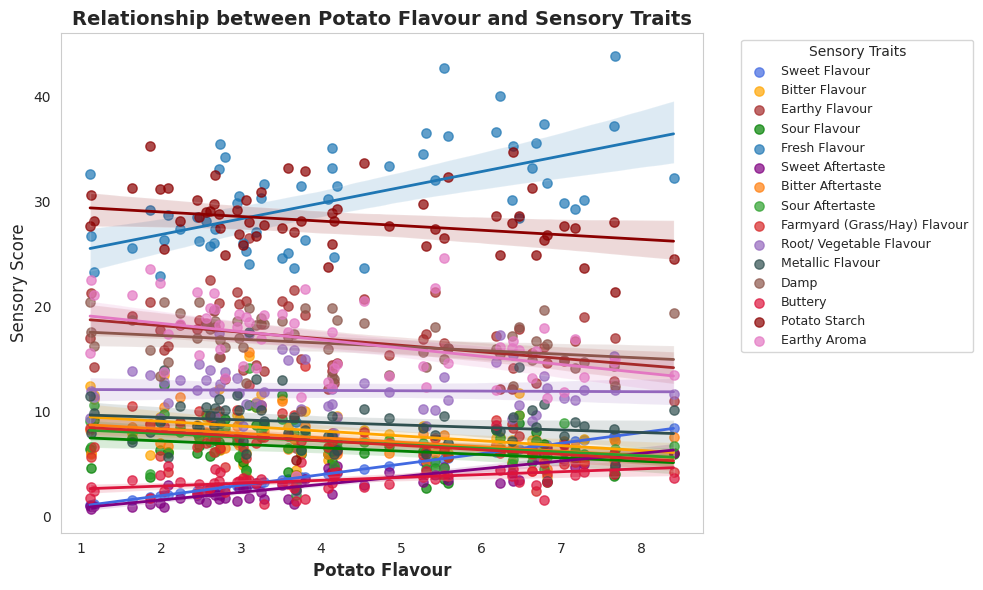

In [0]:

cam.plot_sensory_vs_flavour(sensory_summary, base_trait="SWEET FLAVOUR")


# Predicting the flavors for all the non existing varaieties by using the aroma compounds

In [0]:

merged_aroma_sensory, common = cam.merge_aroma_with_sensory(aroma_sample_df, sensory_summary)


Varieties in Aroma Data   : 95
Varieties in Sensory Data : 59
Common varieties          : 21
Merged varieties          : 21
Merged shape              : (42, 59)


,Variety,(E)-2-Decenal,"1-Hexanol, 2-ethyl-",1-Octen-3-ol,1-Octyn-3-ol,1-Pentanol,1-Penten-3-one,"2,3-Butanedione","2,3-Pentanedione",2-Ethylfuran,2-Methylpropanal,"2-Propanone, 1-methoxy-",3-Carene,3-Methylbutanal,6-Methyl-5-hepten-2-one,"Acetic acid, ethenyl ester","Acetic acid, methyl ester",Benzaldehyde,Benzoic acid,Benzyl alcohol,"Butanal, 3-methyl-",Butanoic acid,Decanal,Dimethyl disulfide,Dimethyl phthalate,Dimethyl trisulfide,Ethyl hexanoate,Eucalyptol,"Furan, 2-pentyl-",Hexanal,Hexanoic acid,Hexanol,Linalool,Nonanal,Pentanal,Phenol,Tetradecane,Tridecane,nonanoic acid,Metallic Flavour,Bitter Flavour,Earthy Flavour,Sour Flavour,Fresh Flavour,Sweet Flavour,Root/ Vegetable Flavour,Farmyard (grass/hay) flavour,Bitter Aftertaste,Sour Aftertaste,Sweet Aftertaste,Earthy Aroma,Farmyard,Sweet,Starchy,Damp,Buttery,Fresh,Potato Starch,Metalic
0,INNOVATOR,504399.0,504399.0,33094.0,504399.0,174987.0,7681.0,585745.0,30272.0,40588.0,47704.0,260467.0,19350.0,1099442.0,7572.0,585745.0,268985.0,239005.0,13962.0,117705.0,48044.0,68173.0,126247.0,319895.0,130904.0,37607.0,86897.0,504399.0,12008.0,29168.0,68173.0,30272.0,46229.0,57168.0,30272.0,64700.0,339253.0,64602.0,48344.0,8.5945,8.7305,17.899,6.102,28.492,2.4455,12.089,6.661,8.592,7.940,2.094,21.417,12.2795,3.548,19.708,16.964,2.2305,30.4405,30.1265,9.8565
1,SMART,274893.0,274893.0,16472.0,274893.0,46457.0,5630.0,159558.0,17992.0,35441.0,22762.0,587414.0,12277.0,247260.0,7429.0,159558.0,291111.0,145501.0,11345.0,256068.0,8394.0,38649.0,114498.0,199484.0,85507.0,15973.0,43453.0,274893.0,7230.0,8892.0,38649.0,17992.0,22135.0,29448.0,17992.0,33765.0,297189.0,47056.0,27411.0,11.5400,9.6550,21.399,7.135,29.840,2.9460,13.208,10.194,8.668,7.484,1.507,18.080,14.2570,4.363,17.501,18.606,3.3180,31.2880,29.1700,6.5410
2,CECILE,1101962.0,1101962.0,60488.0,1101962.0,183896.0,38059.0,1947283.0,1669128.0,2300805.0,324054.0,2183542.0,49396.0,766836.0,371077.0,1947283.0,967609.0,1122396.0,82036.0,53569.0,39032.0,111836.0,326223.0,940393.0,87047.0,72910.0,88572.0,1101962.0,90536.0,4356864.0,111836.0,1669128.0,12646.0,252304.0,1669128.0,96538.0,413238.0,64221.0,71157.0,4.8920,6.3780,17.017,4.065,43.856,7.6710,12.054,5.400,7.238,6.419,4.779,15.012,12.3720,8.568,10.760,12.398,5.7230,38.7930,21.3950,4.2320
3,ORIANA,509980.0,509980.0,24643.0,509980.0,87131.0,8023.0,369443.0,34208.0,37232.0,36574.0,267995.0,10513.0,753895.0,83142.0,369443.0,347413.0,284211.0,12055.0,28438.0,9294.0,35176.0,135440.0,146717.0,123724.0,28109.0,94905.0,509980.0,9072.0,27441.0,35176.0,34208.0,9796.0,61296.0,34208.0,68662.0,374382.0,75467.0,22787.0,9.3740,7.8410,15.410,6.753,33.422,4.8480,11.870,7.007,6.099,7.252,4.239,13.349,15.7860,2.836,16.663,13.501,3.0700,33.5020,27.7050,5.3850
4,SAGITTA,3381099.0,3381099.0,73273.0,3381099.0,1207016.0,28684.0,1220757.0,1101208.0,1181900.0,125783.0,392517.0,18489.0,493183.0,153432.0,1220757.0,396989.0,580543.0,17119.0,116760.0,43608.0,97541.0,316973.0,278196.0,208795.0,88414.0,58757.0,3381099.0,105056.0,3313768.0,97541.0,1101208.0,12232.0,162496.0,1101208.0,234937.0,317114.0,136945.0,108614.0,5.9620,4.8210,12.724,4.571,24.720,4.1560,7.993,3.969,5.956,4.785,4.117,14.185,7.0050,4.458,16.929,13.075,3.8080,30.1200,28.1840,3.9190


Found 38 aroma compounds and 20 sensory traits.
Displaying 35 compounds (threshold=0.2).


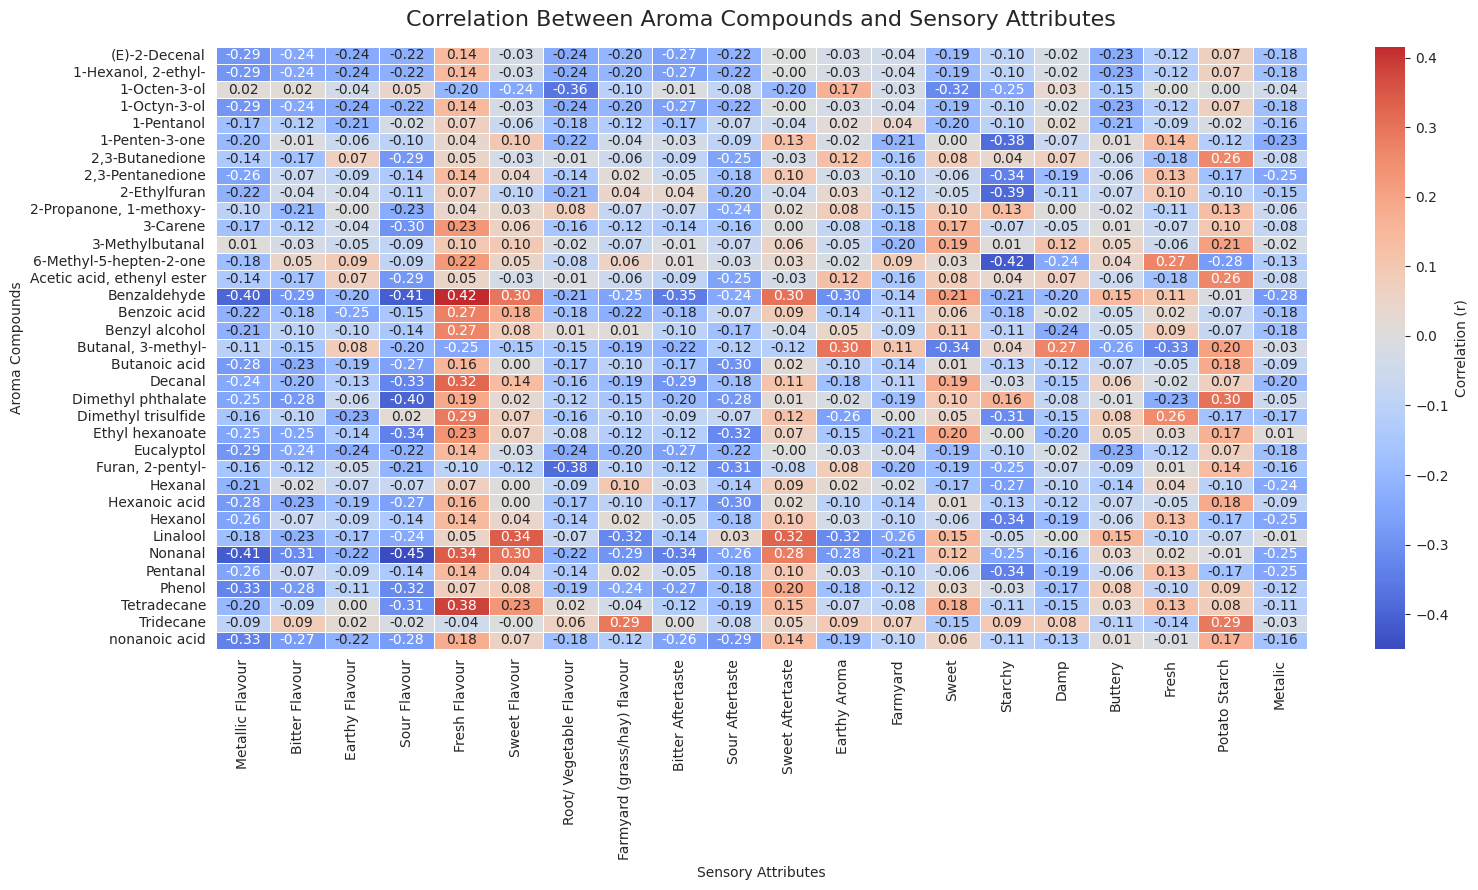

Correlation matrix saved to: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/aroma_sensory_corr_output.csv


In [0]:

# --- Define sensory columns 
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste",
    "Sweet Aftertaste","Earthy Aroma","Farmyard","Sweet","Starchy",
    "Damp","Buttery","Fresh","Potato Starch","Metalic"
]

corr_result = cam.plot_aroma_sensory_correlation(
    merged_aroma_sensory=merged_aroma_sensory,
    sensory_cols=sensory_cols,
    aroma_descriptions=None,  
    threshold=config["settings"]["correlation_threshold"],
    min_compounds=config["settings"]["min_compounds"],
    save_path=config["paths"]["aroma_sensory_corr_output_newharvested"]
)



# Predicting Sensory Scores for Non-panel Varieties using KNN and PCA


Varieties total (aroma): 95
Panel varieties (sensory present): 21
Non-panel varieties (sensory missing): 74

PCA explained variance ratio: [0.45  0.19  0.087]
Total projected varieties: 95


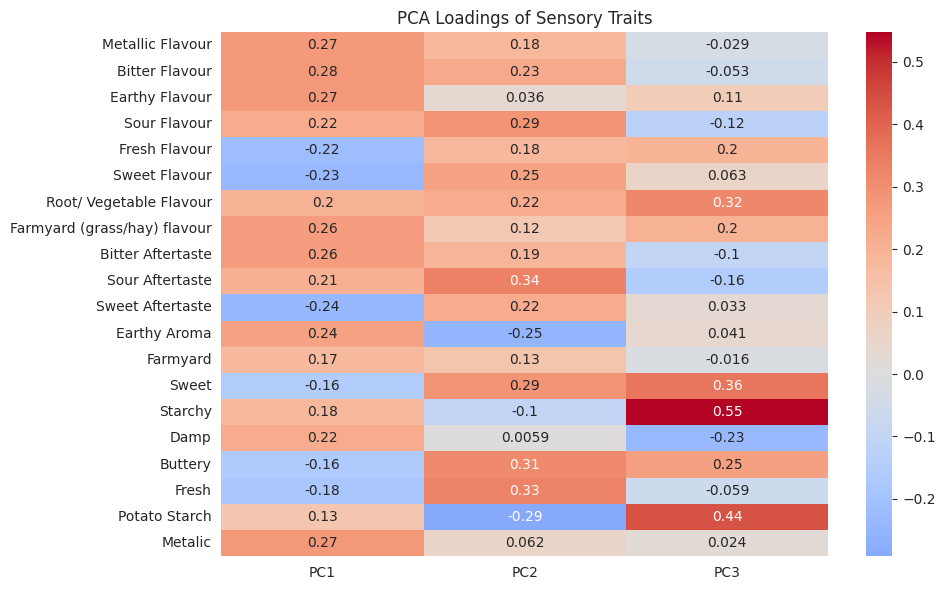

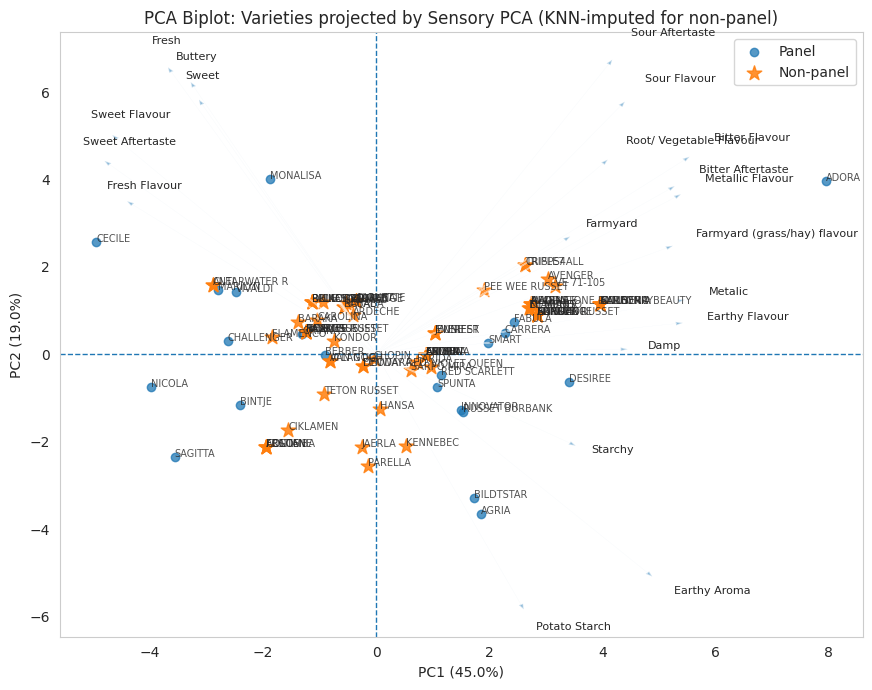

Projection saved to: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/sensory_pca_projection_knn.csv
Loadings saved to: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/sensory_pca_loadings.csv
Files saved:
- /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/sensory_pca_projection_knn.csv
- /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/sensory_pca_loadings.csv
- /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/pc_df.csv


In [0]:

# --- Access paths from config ---
projection_path = config["paths"]["sensory_pca_projection_knn_newharvested"]
loadings_path = config["paths"]["sensory_pca_loadings_newharvested"]
pc_df_path = config["paths"]["sensory_pca_pc_df_newharvested"]

# --- Run the function using paths from config ---
pc_df, pca, loadings_df = cam.perform_knn_sensory_projection(
    aroma_matrix=aroma_sample_df,      
    sensory_summary=sensory_summary,   
    k=3,
    n_components=3,
    scaling_factor=20,
    save_projection_path=projection_path,
    save_loadings_path=loadings_path
)

pc_df.to_csv(pc_df_path, index=False)
print(f"Files saved:\n- {projection_path}\n- {loadings_path}\n- {pc_df_path}")

